In [1]:
from gurobipy import Model, GRB, quicksum
import numpy as np
import pandas as pd

In [3]:
# Load the dataset
data = pd.read_csv("mimic_iv_classification_regression_tasks.csv")
data

,subject_id,stay_id,intime,outtime,Age,gender,ethnicity,insurance,label,dod,hadm_id
0,10000032,39553978,2180-07-23 14:00:00,2180-07-23 23:50:47,52,F,WHITE,Medicaid,0,2180-09-09 00:00:00,29079034
1,10000980,39765666,2189-06-27 08:42:00,2189-06-27 20:38:27,73,F,BLACK/AFRICAN AMERICAN,Medicare,0,2193-08-26 00:00:00,26913865
2,10001217,37067082,2157-11-20 19:18:02,2157-11-21 22:08:00,55,F,WHITE,Other,0,0,24597018
3,10001217,34592300,2157-12-19 15:42:24,2157-12-20 14:27:41,55,F,WHITE,Other,0,0,27703517
4,10001725,31205490,2110-04-11 15:52:22,2110-04-12 23:59:56,46,F,WHITE,Other,0,0,25563031
...,...,...,...,...,...,...,...,...,...,...,...
76938,19999442,32336619,2148-11-19 14:23:43,2148-11-26 13:12:15,41,M,WHITE,Medicaid,0,0,26785317
76939,19999625,31070865,2139-10-10 19:18:00,2139-10-11 18:21:28,81,M,WHITE,Medicare,0,0,25304202
76940,19999828,36075953,2149-01-08 18:12:00,2149-01-10 13:11:02,46,F,WHITE,Other,0,0,25744818
76941,19999840,38978960,2164-09-12 09:26:28,2164-09-17 16:35:15,58,M,WHITE,Other,1,2164-09-17 00:00:00,21033226


In [5]:
# Convert 'intime' to datetime format
data['intime'] = pd.to_datetime(data['intime'])

# Filter records where 'intime' is before 19:00 (7 PM)
filtered_data = data[data['intime'].dt.hour < 19]

# Calculate the required number of rows for label = 0 (10% of 400)
label_0_count = int(0.9 * 300)
label_1_count = 300 - label_0_count

# Separate data by label
label_0_data = filtered_data[filtered_data['label'] == 0]
label_1_data = filtered_data[filtered_data['label'] == 1]

# Ensure there are enough rows to sample
if len(label_0_data) < label_0_count or len(label_1_data) < label_1_count:
    print("Not enough data to meet the requirements.")
else:
    # Randomly sample the required number of rows for each label
    label_0_selected = label_0_data.sample(n=label_0_count, random_state=42)
    label_1_selected = label_1_data.sample(n=label_1_count, random_state=42)

    # Combine the selected data
    final_data = pd.concat([label_0_selected, label_1_selected])

    # Add a column for hour and minute as a decimal
    final_data['time_decimal'] = final_data['intime'].dt.hour + final_data['intime'].dt.minute / 60

    # Select only the required columns
    final_data = final_data[['subject_id', 'intime', 'label', 'time_decimal']]

    # Save the filtered data to a new CSV file
    output_path = "filtered_patient_data.csv"  # Specify your output file path
    final_data.to_csv(output_path, index=False)
    print(f"Filtered data saved to {output_path}")


Filtered data saved to filtered_patient_data.csv


In [7]:
final_data = pd.read_csv("filtered_patient_data.csv")
final_data

,subject_id,intime,label,time_decimal
0,14624336,2155-04-27 18:19:34,0,18.316667
1,11478524,2148-01-20 18:55:09,0,18.916667
2,16013718,2136-01-26 02:12:18,0,2.200000
3,16661755,2174-06-08 00:24:00,0,0.400000
4,15040979,2120-03-26 13:04:23,0,13.066667
...,...,...,...,...
295,14912212,2121-11-29 03:35:46,1,3.583333
296,16486158,2152-07-31 18:26:00,1,18.433333
297,12953729,2174-11-05 17:14:21,1,17.233333
298,10517819,2180-08-22 16:02:31,1,16.033333


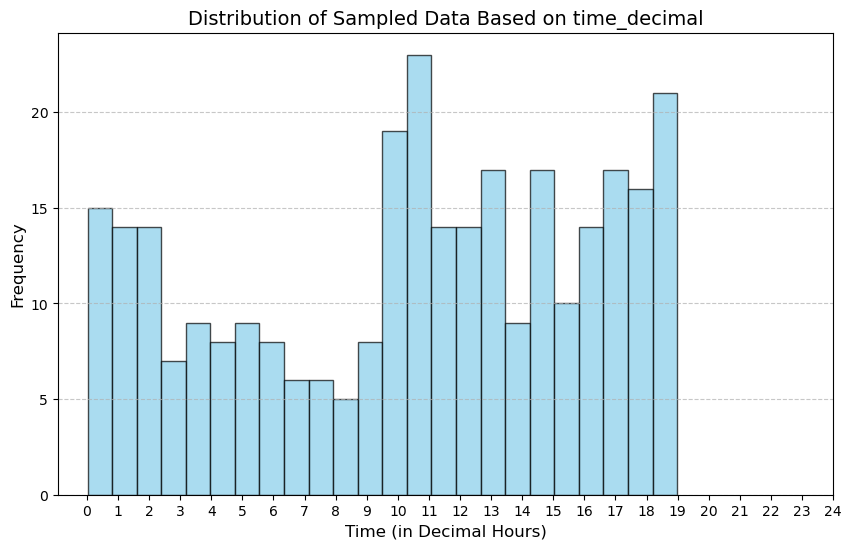

In [9]:
import matplotlib.pyplot as plt

# Assuming 'final_data' contains the filtered data
plt.figure(figsize=(10, 6))
plt.hist(final_data['time_decimal'], bins=24, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sampled Data Based on time_decimal', fontsize=14)
plt.xlabel('Time (in Decimal Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(0, 25))
plt.show()

In [11]:
# Initialize model
model = Model("ED_Nurse_Assignment")

Set parameter Username
Academic license - for non-commercial use only - expires 2025-08-30


In [13]:
# Define parameters
n = 140  # Number of nurses
m = len(final_data)  # Number of patients
areas = ["resus", "registration", "triage", "consultation", "observation"]
time_slots = [32, 288, 288, 72, 12]  # Number of time slots for each area
s = [0.75, 0.08, 0.08, 0.33, 2]  # Transition times between areas
arrival_time = final_data['time_decimal'].tolist()  # Patient arrival times
r = final_data['label'].tolist()  # Resuscitation need (binary: 1 if needed)

In [15]:
# Slot start times for each area
slot_start_times = [
    [i * s[k] for i in range(time_slots[k])] for k in range(len(areas))
]

In [17]:
# Decision variables
x = {k: model.addVars(m, time_slots[k], vtype=GRB.BINARY, name=f"x_{k}") for k in range(len(areas))}  # Patient in area/time
y = model.addVars(n, len(areas), max(time_slots), vtype=GRB.BINARY, name="y")  # Nurse assignment by time slot
available = model.addVars(n, max(time_slots), vtype=GRB.BINARY, name="available")  # Nurse availability
arrival = model.addVars(m, len(areas), vtype=GRB.CONTINUOUS, name="arrival")  # Patient arrival time in area
waiting_time = model.addVars(m, len(areas), vtype=GRB.CONTINUOUS, name="waiting_time")  # Patient waiting time

# Objective function: Minimize total waiting time
model.setObjective(
    quicksum(waiting_time[i, k] for i in range(m) for k in range(len(areas))),
    GRB.MINIMIZE
)

In [19]:
# (1) Each nurse can only be in one area at a time slot
for j in range(n):
    for a in range(max(time_slots)):
        model.addConstr(
            quicksum(y[j, k, a] for k in range(len(areas))) <= 1,
            name=f"NurseSingleArea_Time{a}_{j}"
        )

# (2) Nurse availability updates dynamically
for j in range(n):
    for a in range(1, max(time_slots)):
        model.addConstr(
            available[j, a] >= available[j, a-1] - quicksum(
                x[k][i, a-1] for k in range(len(areas)) for i in range(m) if a-1 < time_slots[k]
            ),
            name=f"NurseAvailability_{j}_{a}"
        )

# (3) Each patient is treated in only one time slot per area (except resus)
for i in range(m):
    for k in range(1, len(areas)):  # Areas excluding resus
        model.addConstr(
            quicksum(x[k][i, a] for a in range(time_slots[k])) == 1,
            name=f"SingleStart_Patient{i}_Area{k}"
        )

# (4) Resus-specific constraints for arrival
for i in range(m):
    if r[i] == 1:  # Patient needs resus
        model.addConstr(arrival[i, 0] == arrival_time[i], name=f"Arrival_Resus_{i}")
    else:  # Patient does not need resus
        model.addConstr(arrival[i, 0] == 1000000, name=f"Arrival_NonResus_{i}")  # Big M for non-resus patients

# (5) Arrival time calculations for subsequent areas
for i in range(m):
    for k in range(1, len(areas)):
        model.addConstr(
            arrival[i, k] == s[k-1] + quicksum(
                x[k-1][i, a] * slot_start_times[k-1][a] for a in range(time_slots[k-1])
            ),
            name=f"Arrival_Other_{i}_Area{k}"
        )

# (6) Waiting time calculation
for i in range(m):
    for k in range(len(areas)):
        if k == 0 and r[i] == 0:  # Patients not needing resus
            model.addConstr(waiting_time[i, k] == 0, name=f"WaitingTime_NoResus_{i}")
        else:
            model.addConstr(
                waiting_time[i, k] == quicksum(
                    x[k][i, a] * slot_start_times[k][a] for a in range(time_slots[k])
                ) - arrival[i, k],
                name=f"WaitingTime_{i}_Area{k}"
            )

# (7) Total nurses assigned cannot exceed available nurses
for k in range(len(areas)):
    for a in range(time_slots[k]):
        model.addConstr(
            quicksum(x[k][i, a] for i in range(m)) <= quicksum(y[j, k, a] for j in range(n)),
            name=f"PatientNurseLimit_{k}_{a}"
        )

# (8) Minimum one nurse per area at all times
for k in range(len(areas)):
    for a in range(time_slots[k]):
        model.addConstr(
            quicksum(y[j, k, a] for j in range(n)) >= 1,
            name=f"MinOneNurse_Area{k}_Time{a}"
        )


In [ ]:
# Solve the model
model.optimize()

# Display results
if model.status == GRB.OPTIMAL:
    print("Optimal solution found!")
    
    # Nurse Allocations: Count nurses assigned to each area
    nurse_counts = [0] * len(areas)
    for k in range(len(areas)):
        for j in range(n):
            if any(y[j, k, a].x > 0.5 for a in range(time_slots[k])):
                nurse_counts[k] += 1
    
    print("\nTotal Number of Nurses Allocated in Each Area:")
    for k, count in enumerate(nurse_counts):
        print(f"Area {areas[k]}: {count} nurses")
    
    # Total waiting time per area
    total_waiting_times = [0] * len(areas)
    for k in range(len(areas)):
        for i in range(m):
            total_waiting_times[k] += waiting_time[i, k].x
    
    print("\nTotal Waiting Times in Each Area:")
    for k, total_time in enumerate(total_waiting_times):
        print(f"Area {areas[k]}: {total_time:.2f} time units")
else:
    print("No optimal solution found.")


Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 86084 rows, 452520 columns and 30266080 nonzeros
Model fingerprint: 0x42a7ca49
Variable types: 3000 continuous, 449520 integer (449520 binary)
Coefficient statistics:
  Matrix range     [8e-02, 2e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e-02, 1e+06]
Presolve removed 0 rows and 0 columns (presolve time = 5s) ...
Presolve removed 0 rows and 105000 columns (presolve time = 14s) ...
Presolve removed 280 rows and 105000 columns (presolve time = 16s) ...
Presolve removed 850 rows and 105570 columns (presolve time = 23s) ...
Presolve removed 850 rows and 106150 columns (presolve time = 31s) ...
Presolve removed 1691 rows and 106990 columns (presolve time = 41s) ...
Preso